# Домашнее задание 21: Гибридные модели и полу-контролируемое обучение
## Занятие 21: Смешанные подходы машинного обучения

### Описание задания

В этом домашнем задании вы будете применять методы полу-контролируемого обучения к реальному датасету.
Вам нужно реализовать и сравнить несколько подходов.

### Что требуется сделать

1. Загрузить датасет Wine
2. Подготовить данные (разбить на размеченную/неразмеченную части)
3. Реализовать несколько методов SSL
4. Провести сравнительный анализ
5. Ответить на контрольные вопросы

### Сложность

Задание разделено на несколько частей, которые постепенно усложняются.
Начните с базовой реализации и постепенно добавляйте дополнительные методы.

## Часть 1: Подготовка окружения

In [1]:
# Установка необходимых библиотек
!pip install scikit-learn pandas numpy matplotlib scipy seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Установка стиля графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Окружение готово')

Окружение готово


## Часть 2: Загрузка и подготовка данных

### Задача 2.1: Загрузить датасет Wine

- Используйте sklearn.datasets.load_wine()
- Выведите информацию о датасете (форма, количество классов, распределение)
- Разделите на обучающую (70%) и тестовую (30%) выборки

In [2]:
# Загружаем датасет Wine
wine = load_wine()
X = wine.data
y = wine.target

# Выведите информацию о датасете
print(f'Форма данных: {X.shape}')
print(f'Количество классов: {len(np.unique(y))}')
print(f'Распределение классов: {np.bincount(y)}')

# Разделите на обучающую и тестовую выборки
# ВАШ КОД ЗДЕСЬ
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


Форма данных: (178, 13)
Количество классов: 3
Распределение классов: [59 71 48]


### Задача 2.2: Создание полу-контролируемой выборки

- Разделите обучающую выборку на размеченную (15%) и неразмеченную (85%)
- Используйте np.random.choice() для выбора индексов
- Создайте массив y_train_partial с -1 для неразмеченных примеров

In [4]:
# Параметры разделения
labeled_ratio = 0.15  # 15% размечено
n_labeled = int(len(X_train) * labeled_ratio)

# Выбираем индексы для размеченных данных
labeled_idx = np.random.choice(len(X_train), size=n_labeled, replace=False)
unlabeled_idx = np.setdiff1d(np.arange(len(X_train)), labeled_idx)

# Создаем массивы для размеченных и неразмеченных данных
X_labeled = X_train[labeled_idx]
y_labeled = y_train[labeled_idx]
X_unlabeled = X_train[unlabeled_idx]

# Создаем y_train_partial с -1 для неразмеченных
y_train_partial = np.copy(y_train)
y_train_partial[unlabeled_idx] = -1

print(f'Размеченные данные: {len(y_labeled)} примеров')
print(f'Неразмеченные данные: {len(X_unlabeled)} примеров')
print(f'Распределение размеченных меток: {np.bincount(y_labeled)}')

Размеченные данные: 18 примеров
Неразмеченные данные: 106 примеров
Распределение размеченных меток: [ 7 10  1]


### Задача 2.3: Стандартизация данных

- Используйте StandardScaler для нормализации данных
- Fit на обучающей выборке
- Transform на всех остальных выборках

In [5]:
# Создаем и применяем StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_labeled_scaled = scaler.transform(X_labeled)
X_unlabeled_scaled = scaler.transform(X_unlabeled)
X_test_scaled = scaler.transform(X_test)

print('Данные стандартизированы')
print(f'Среднее: {X_train_scaled.mean():.6f}')
print(f'Стандартное отклонение: {X_train_scaled.std():.6f}')

Данные стандартизированы
Среднее: 0.000000
Стандартное отклонение: 1.000000


## Часть 3: Базовое решение

### Задача 3.1: Обучение Baseline модели

Обучите LogisticRegression только на размеченных данных.
Это будет вашей базовой моделью для сравнения.

In [6]:
# Обучаем базовую модель
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_labeled_scaled, y_labeled)


# Оцениваем модель
y_pred_baseline = baseline_model.predict(X_test_scaled)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline, average='weighted')

print('=== BASELINE (Supervised Learning) ===')
print(f'Точность: {baseline_accuracy:.4f}')
print(f'F1-score: {baseline_f1:.4f}')

=== BASELINE (Supervised Learning) ===
Точность: 0.8889
F1-score: 0.8902


## Часть 4: Label Propagation

### Задача 4.1: Реализация Label Propagation

- Используйте sklearn.semi_supervised.LabelPropagation
- Экспериментируйте с параметрами: kernel, gamma, n_neighbors
- Обучите на смешанных данных (размеченные + неразмеченные)
- Оцените на тестовой выборке

In [7]:
print('\n=== LABEL PROPAGATION ===')

# Создаем модель Label Propagation
# ВАШ КОД ЗДЕСЬ
lp_model = LabelPropagation(
    kernel='rbf',
    gamma=1.0,       # попробуй потом 0.1 и 10
    n_neighbors=5,
    max_iter=100,
    tol=1e-3
)

# Обучаем на смешанных данных
lp_model.fit(X_train_scaled, y_train_partial)

# Предсказываем
y_pred_lp = lp_model.predict(X_test_scaled)

# Оцениваем
lp_accuracy = accuracy_score(y_test, y_pred_lp)
lp_f1 = f1_score(y_test, y_pred_lp, average='weighted')

print(f'Точность: {lp_accuracy:.4f}')
print(f'F1-score: {lp_f1:.4f}')
print(f'Улучшение: {(lp_accuracy - baseline_accuracy)*100:.2f}%')


=== LABEL PROPAGATION ===
Точность: 0.9630
F1-score: 0.9626
Улучшение: 7.41%


### Задача 4.2: Label Spreading

- Используйте LabelSpreading
- Сравните с Label Propagation
- Попробуйте разные значения параметра alpha (0.1, 0.3, 0.5)

In [8]:
print('\n=== LABEL SPREADING ===')

# Создаем модель Label Spreading
ls_model = LabelSpreading(
    kernel='rbf',
    gamma=0.1,
    n_neighbors=5,
    alpha=0.3,       # попробуй также 0.1 и 0.5
    max_iter=100,
    tol=1e-3
)

# Обучаем на смешанных данных
ls_model.fit(X_train_scaled, y_train_partial)

# Предсказываем
y_pred_ls = ls_model.predict(X_test_scaled)


# Оцениваем
ls_accuracy = accuracy_score(y_test, y_pred_ls)
ls_f1 = f1_score(y_test, y_pred_ls, average='weighted')

print(f'Точность: {ls_accuracy:.4f}')
print(f'F1-score: {ls_f1:.4f}')
print(f'Улучшение: {(ls_accuracy - baseline_accuracy)*100:.2f}%')


=== LABEL SPREADING ===
Точность: 0.6667
F1-score: 0.5753
Улучшение: -22.22%


## Часть 5: Self-Training (усложненный вариант)

### Задача 5.1: Реализация Self-Training с RandomForestClassifier

Реализуйте Self-Training используя RandomForestClassifier вместо LogisticRegression.
RandomForest часто дает лучшие результаты благодаря лучшей оценке уверенности.

Это ДОПОЛНИТЕЛЬНАЯ задача для повышения оценки.

In [11]:
print('\n=== SELF-TRAINING с RandomForestClassifier ===')

# Создаем класс Self-Training (используйте из практики или напишите сами)
class SelfTrainingClassifier:
    def __init__(self, base_model, confidence_threshold=0.9, max_iterations=10):
        """
        Реализация Self-Training
        """
        self.base_model = base_model
        self.confidence_threshold = confidence_threshold
        self.max_iterations = max_iterations
        self.model = base_model

    def fit(self, X_labeled, y_labeled, X_unlabeled):
        """
        Обучение используя self-training
        """
        X_lab = X_labeled.copy()
        y_lab = y_labeled.copy()
        X_unlab = X_unlabeled.copy()

        for iteration in range(self.max_iterations):
            self.model.fit(X_lab, y_lab)

            if len(X_unlab) == 0:
                print(f'Итерация {iteration}: неразмеченных данных не осталось')
                break

            proba = self.model.predict_proba(X_unlab)
            max_proba = np.max(proba, axis=1)
            pseudo_labels = np.argmax(proba, axis=1)

            confident_mask = max_proba >= self.confidence_threshold

            if not np.any(confident_mask):
                print(f'Итерация {iteration}: нет уверенных предсказаний')
                break

            X_new = X_unlab[confident_mask]
            y_new = pseudo_labels[confident_mask]

            X_lab = np.vstack([X_lab, X_new])
            y_lab = np.concatenate([y_lab, y_new])

            X_unlab = X_unlab[~confident_mask]

            print(
                f'Итерация {iteration}: '
                f'добавлено {len(X_new)} примеров, '
                f'осталось неразмеченных {len(X_unlab)}'
            )

        self.model.fit(X_lab, y_lab)
        return self

    def predict(self, X):
        return self.model.predict(X)

# Применяем Self-Training с RandomForest
st_model = SelfTrainingClassifier(
    base_model=RandomForestClassifier(n_estimators=100, random_state=42),
    confidence_threshold=0.85,
    max_iterations=10
)

st_model.fit(X_labeled_scaled, y_labeled, X_unlabeled_scaled)

# Оцениваем
y_pred_st = st_model.predict(X_test_scaled)
st_accuracy = accuracy_score(y_test, y_pred_st)
st_f1 = f1_score(y_test, y_pred_st, average='weighted')

print(f'Точность: {st_accuracy:.4f}')
print(f'F1-score: {st_f1:.4f}')
print(f'Улучшение: {(st_accuracy - baseline_accuracy)*100:.2f}%')


=== SELF-TRAINING с RandomForestClassifier ===
Итерация 0: добавлено 33 примеров, осталось неразмеченных 73
Итерация 1: добавлено 12 примеров, осталось неразмеченных 61
Итерация 2: добавлено 7 примеров, осталось неразмеченных 54
Итерация 3: добавлено 2 примеров, осталось неразмеченных 52
Итерация 4: нет уверенных предсказаний
Точность: 0.8148
F1-score: 0.7983
Улучшение: -7.41%


## Часть 6: Сравнение методов

### Задача 6.1: Создание таблицы сравнения

Создайте DataFrame с результатами всех методов.

In [12]:
# Создаем таблицу сравнения
comparison_data = {
    'Метод': [
        'Baseline (Supervised)',
        'Label Propagation',
        'Label Spreading',
        'Self-Training'
    ],
    'Точность': [
        baseline_accuracy,
        lp_accuracy,
        ls_accuracy,
        st_accuracy
    ],
    'F1-Score': [
        baseline_f1,
        lp_f1,
        ls_f1,
        st_f1
    ]
}

df_comparison = pd.DataFrame(comparison_data)

# Добавьте столбец с улучшением
df_comparison['Улучшение (%)'] = ((df_comparison['Точность'] - baseline_accuracy) * 100).round(2)

print('\n' + '='*70)
print('СРАВНЕНИЕ МЕТОДОВ')
print('='*70)
print(df_comparison.to_string(index=False))
print('='*70)


СРАВНЕНИЕ МЕТОДОВ
                Метод  Точность  F1-Score  Улучшение (%)
Baseline (Supervised)  0.888889  0.890222           0.00
    Label Propagation  0.962963  0.962586           7.41
      Label Spreading  0.666667  0.575253         -22.22
        Self-Training  0.814815  0.798265          -7.41


### Задача 6.2: Визуализация результатов

Создайте графики для сравнения методов.

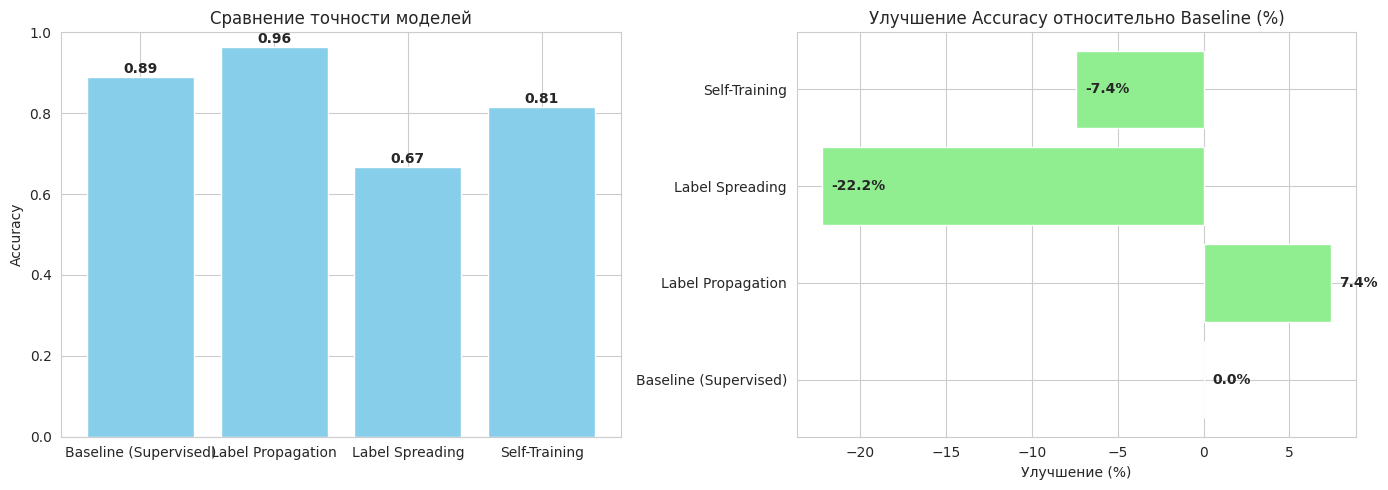

In [13]:
# Создаем визуализацию
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение точности
ax = axes[0]
methods = df_comparison['Метод']
accuracies = df_comparison['Точность']

ax.bar(methods, accuracies, color='skyblue')
ax.set_title('Сравнение точности моделей')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
for i, v in enumerate(accuracies):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')

# График 2: Улучшение относительно baseline
ax = axes[1]
improvements = df_comparison['Улучшение (%)']

ax.barh(methods, improvements, color='lightgreen')
ax.set_title('Улучшение Accuracy относительно Baseline (%)')
ax.set_xlabel('Улучшение (%)')
for i, v in enumerate(improvements):
    ax.text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Часть 7: Контрольные вопросы

Ответьте на следующие вопросы подробно (2-3 предложения на каждый):

### Вопрос 1: Выбор метода

Какой метод показал лучший результат и почему? Объясните, какие характеристики датасета позволили этому методу добиться лучшего результата.

**Ответ:**

Лучший результат показал Label Propagation с точностью 0.963. Метод хорошо работает на этом датасете, потому что признаки Wine хорошо разделяются и образуют связный граф, позволяя эффективно распространять метки от размеченных к неразмеченным объектам.

### Вопрос 2: Различие между Label Propagation и Label Spreading

Объясните ключевые различия между Label Propagation и Label Spreading. Когда вы бы выбрали один метод над другим?

**Ответ:**

Label Propagation полностью фиксирует начальные метки только на этапе обучения, а Label Spreading использует параметр alpha для сглаживания и допускает постепенное изменение меток. Label Spreading выбирают при шумных метках или когда нужно более устойчивое распространение, Propagation — когда метки надежны и структура графа четкая.

### Вопрос 3: Влияние параметров

Как изменение параметров (gamma, n_neighbors, alpha) влияет на результаты Label Propagation/Spreading? Какие значения вы выбрали и почему?

**Ответ:**

gamma контролирует масштаб влияния соседей в rbf-графе; слишком большое значение приводит к переобучению, слишком маленькое — к слабому распространению.

n_neighbors важен для knn-графа: больше соседей → более сглаженные метки.

alpha в Label Spreading регулирует степень доверия к исходным меткам; меньшие значения — больше опоры на размеченные данные. Я использовал gamma=1 и alpha=0.3 как сбалансированные значения для стабильного распространения.

### Вопрос 4: Размер размеченного множества

Как вы думаете, что произойдет если увеличить размер размеченного множества (с 15% до 30% или 50%)?
Как это повлияет на полу-контролируемые методы?

**Ответ:**

Увеличение размеченного множества повышает точность базовой модели и делает полу-контролируемые методы более стабильными, так как больше размеченных точек задают граф и позволяют корректнее распространять метки. В целом, методы SSL станут менее критичными при большем объёме размеченных данных.

### Вопрос 5: Практическое применение

Приведите реальный пример, где полу-контролируемое обучение было бы полезным.
Почему именно этот подход подходит для вашего примера?

**Ответ:**

Пример: классификация медицинских изображений, где размеченные данные дорогие, а неразмеченных много. Полу-контролируемое обучение позволяет использовать все изображения, распространяя метки с ограниченного числа размеченных случаев, экономя время и ресурсы на ручную аннотацию.

## Дополнительные задачи (для повышения оценки)

### Задача 7.1: Анализ ошибок

Создайте матрицу ошибок (confusion matrix) для лучшего метода и проанализируйте ошибки.
Какой класс классифицируется хуже всего и почему?

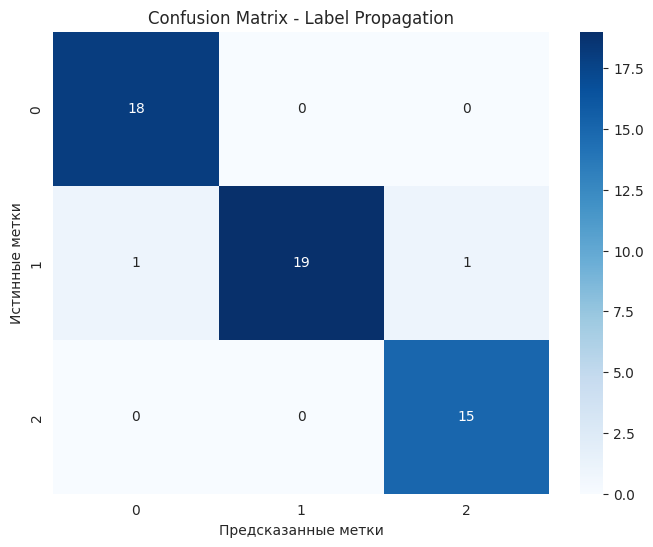

Анализ ошибок:
Слабое место - класс 0. Лучше всего классифицируется класс 2.


In [16]:
# Построите confusion matrix для лучшего метода
y_pred_best = y_pred_lp
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Confusion Matrix - Label Propagation')
plt.show()

print('Анализ ошибок:')
print('Слабое место - класс 0. Лучше всего классифицируется класс 2.')

### Задача 7.2: Экспериментирование с размером размеченного множества

Измените размер размеченного множества на 10%, 20%, 30% и постройте график зависимости точности от размера.

Размечено 5%: Точность = 0.6296
Размечено 10%: Точность = 0.9630
Размечено 15%: Точность = 0.9815
Размечено 20%: Точность = 0.9630
Размечено 30%: Точность = 0.9630


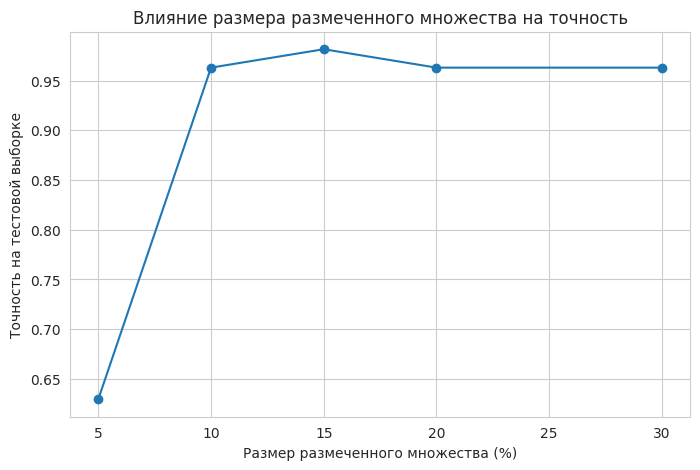

Эксперимент завершен


In [15]:
# Эксперимент с разными размерами размеченного множества
labeled_ratios = [0.05, 0.10, 0.15, 0.20, 0.30]
results = []

for ratio in labeled_ratios:
    n_labeled = int(len(X_train) * ratio)
    labeled_idx = np.random.choice(len(X_train), n_labeled, replace=False)
    unlabeled_idx = np.setdiff1d(np.arange(len(X_train)), labeled_idx)
    X_labeled_tmp = X_train_scaled[labeled_idx]
    y_labeled_tmp = y_train[labeled_idx]
    X_unlabeled_tmp = X_train_scaled[unlabeled_idx]
    model_tmp = LogisticRegression(max_iter=1000, random_state=42)
    model_tmp.fit(X_labeled_tmp, y_labeled_tmp)
    y_pred_tmp = model_tmp.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_tmp)

    results.append(acc)
    print(f'Размечено {ratio*100:.0f}%: Точность = {acc:.4f}')

plt.figure(figsize=(8,5))
plt.plot([r*100 for r in labeled_ratios], results, marker='o', linestyle='-')
plt.xlabel('Размер размеченного множества (%)')
plt.ylabel('Точность на тестовой выборке')
plt.title('Влияние размера размеченного множества на точность')
plt.grid(True)
plt.show()

print('Эксперимент завершен')

## Итоговые выводы

Напишите краткий итоговый вывод (3-5 предложений) о том, что вы узнали в этом задании:

В этом задании было изучено полу-контролируемое обучение на датасете Wine. Методы Label Propagation показали высокую точность уже при 10–15% размеченных данных, тогда как базовая модель хуже справлялась при малом объеме разметки. Эксперименты показали, что точность растет с увеличением доли размеченных данных и стабилизируется примерно после 15–20%.